# QOSF Screening Task: Quantum Support Vector Machine

In this notebook, we shall attempt to create a Quantum version of the Support Vector Machine classifier using the Iris dataset. The work involves the usage of a quantum circuit to create the kernel matrix required for SVM to operate, and corresponding to the kernal matrix we can then have a test matrix to measure the accuracy of our trained model. We also present the classical benchmark, and put forward a quantum circuit which allows us to beat the said classical benchmark!

#### Author: Gaurav Rudra Malik, Date: 24th October 2025

## Introduction

In this demonstration we shall be simulating the circuit dynamics, i.e. generating results without implementing the circuit on an acutal quantum computer. Now, this task is generally challenging for a classical computer, particularly my modestly speced laptop! In order to accomplish this task efficiently, we shall use a **tensor-based implementation** taking our quantum states and unitary operators as appropriately designed tensors making use of which we can construct our circuit. 

In many-body physics, this is a frequently used method which allows for the classical simulation of a wide array of physical models, and forms the basis of the widely used **tensor networks** paradigm. While we shall not be using the entanglement based dimensionality reduction that underlines tensor networks methods in techniques such as DMRG and TEBD, we shall still be able to apply operators on quantum states without the requirement of identity matrix padding which takes up significant memory resources. 

Basically, we shall be able to implement single and two body quantum gates, at their respective qubits using the tensor approach, reducing our memory requirement, while also making the process much faster when using a classical setup.

## The Tensor Approach

For a state of say, four number of qubits, an arbitrary state can be expressed as a superposition over all basis states as follows:

\begin{equation*}
	|\psi\rangle = \sum_{\{ \sigma \}} c_{\sigma_1,\sigma_2,\sigma_3,\sigma_4} |\sigma_1,\sigma_2,\sigma_3,\sigma_4\rangle
\end{equation*}

This state can be represented as a rank-4 tensor containing all the basis coefficients, $C_{\sigma_1,\sigma_2,\sigma_3,\sigma_4}$ and graphically corresponds to a figure with 4 open legs. Now, suppose that we wish to apply a single qubit operation on a particular qubit, say 3rd, we can do that with a tensor operation.

Let the operator required be given by $U$, which would be a $2 \times 2$ matrix. This matrix can be equivalently be represented as $U_{\alpha \beta}$, and the action of this matrix on the state $|\psi\rangle$ when applied on the third qubit is given by the respective tensor contraction.

Let us define $|\phi\rangle = U|\psi\rangle$. Similar to $\psi$, $\phi$ would also be a rank-4 tensor, and the application of gate $U$ to $\psi$ can then be given as:
\begin{equation*}
\phi_{\sigma_1,\sigma_2,\alpha,\sigma_3} = U_{\alpha \beta}\psi_{\sigma_1,\sigma_2,\beta,\sigma_3}
\end{equation*}

Here we have used the Einstein Summation Convention and the contraction of tensors. Note that only the third index is contracted, as the operator was assumed to be acting on the third qubit.

Compare this to the actual matrix multiplication, taking $|\psi\rangle$ and $|\phi\rangle$ as column vectors and $U$ as $\mathbb{I} \otimes \mathbb{I} \otimes U \otimes \mathbb{I}$. The same operation is then given by $|\phi\rangle = U|\psi\rangle$. Here $\mathbb{I}$ represents the identity matrix.

The said tensor manipulations can be easily performed using numpy's tensordot feature, as we shall now show.

In [1]:
import numpy as np

N = 4 # Taking a 4 qubit system
d = 2**N # Magnitude of Hilbert Space

basis = np.eye(d) # Collection of all basis vectors
state = basis[0] # say, psi is |0000>

# We shall now apply the X operator on the third qubit.
# This will give us |0010> state, i.e. the state given by basis[2]

# Defining the operator
X = np.array([[0,1],[1,0]])

# Defining the state and operator as tensors:
state = state.reshape((2,)*N)
X = X.reshape(2,2)

# Applying the tensor contraction
# Contracting the 2nd index (labelled as 1) of X with the 3rd index (labelled as 2) of psi.
state_phi = np.tensordot(X,state,(1,2))
state_phi = np.moveaxis(state_phi,0,2)

# Printing the final state in vector form
print('Vector form of phi:', state_phi.flatten())

# Verifying overlap with the expected result state
print('Overlap with basis state |0010>:', np.vdot(state_phi,basis[2]))

Vector form of phi: [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Overlap with basis state |0010>: 1.0


We shall use these computations exlusively in this notebook, without using any libraries at all from packages like Qiskit or Qutip.

### References:

https://www.kattemolle.com/other/QCinPY.html 


https://numpy.org/doc/2.1/reference/generated/numpy.tensordot.html

## Classical Pre-Processing of Data

For a quantum machine learning protocol, data is taken from the source and encoded with quantum states. However, before the encoding can begin, the data must be properly normalised for it to represent relevant physical features. We now introduce our subroutine for this normalisation.

In [2]:
# Subroutine for normalising the parameter values
# A classical preprocessing step for this specific algorithm
# It normalises the values of the given feature vector between 0 and 1

def normalized_values(data):
    min_data = min(data)
    max_data = max(data)
    
    data = [i/max_data for i in data]

    data = np.array(data, dtype = complex)
    return data

This subroutine takes an input data set and returns the same values normalised between 0 and 1. We shall use this subroutine on our dataset while implementing the quantum protocols. The protocols for data encoding and machine learning move forward via the use of parameterized quantum circuits, where the parameters are dependent on the normalised values of the feature vectors within the dataset.

## Classification Using Iris Data Set

We shall start by uploading the Iris data set and establishing some classical benchmarks.

In [3]:
# Importing Packages

import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import scipy.linalg as la
import matplotlib.pyplot as plt

We begin by uploading the datafile as a pandas dataframe, before implementing a train-test split. We establish classical SVM benchmarks before implementing quantum circuits for the same task.

## Uploading Data and Train-Test Splitting

We upload the Iris dataset onto our program and take a 60-40 split between training and testing samples. We also remove the labels and IDs to keep only numerical data in the feature vectors. The labels are separately taken into their own specific vectors.

In [4]:
# Load the Iris dataset

df = pd.read_csv("Iris.csv")

# Separating the features (X) and labels (y)

X = df.drop(['Id', 'Species'], axis=1).values  # All columns except Id and Species
y = df['Species'].values  # The target column

# We now split the data between the test and training segments

X_train, X_test, train_labels, test_labels = train_test_split(
    X, y, 
    test_size=0.4,  # This ratio implements a 60-40 split
    stratify=y,     # Ensures that all datatypes are in the split
    random_state=42  # For introducing reproducibility
)

# Verify the split

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Training labels: {np.unique(train_labels, return_counts=True)}")
print(f"Test labels: {np.unique(test_labels, return_counts=True)}")

train_size = len(X_train)
test_size = len(X_test)

# We also transform the labels into numerical data

le = LabelEncoder()
train_labels_encoded = le.fit_transform(train_labels)
test_labels_encoded = le.transform(test_labels)

print(f"\nEncoded training labels: {np.unique(train_labels_encoded)}")
print(f"Encoded test labels: {np.unique(test_labels_encoded)}")
print(f"Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Training set size: 90
Test set size: 60
Training labels: (array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object), array([30, 30, 30]))
Test labels: (array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object), array([20, 20, 20]))

Encoded training labels: [0 1 2]
Encoded test labels: [0 1 2]
Label mapping: {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}


From the training and test data we make a set of feature vectors for both categories that shall be used extensively for the purpose of training and validating the different QSVM models.

In [5]:
# Taking the independent feature vectors from the dataset

feature_vectors = [X_train[i] for i in range(len(X_train))]
feature_vectors_test = [X_test[i] for i in range(len(X_test))]

##  Setting up Classical Benchmark

Before proceeding with the different models for Quantum SVM, we shall establish a benchmark for the classical case, using the data we have obtained from the Iris dataset. This has the same train-test split as we shall be using for the quantum approach.

In [6]:
# Using the classical RBF Kernel for establishing benchmarks.

clf = SVC(kernel='rbf')
clf.fit(X_train, train_labels)
print("Classical Benchmark")
print("RBF test accuracy:", round(clf.score(X_test, test_labels),5))

Classical Benchmark
RBF test accuracy: 0.96667


The RBF (Radial Basis Function) kernel maps data into a higher-dimensional space using a Gaussian similarity measure, allowing SVMs to capture nonlinear relationships that simple linear kernels cannot. Here we see that on the Iris dataset, RBF has an accuracy of 96.6%

## Setting up the Quantum Circuit

Based on the number of parameters, we take the corresponding number of qubits. It comes out to be 4 for the Iris dataset. This is a very managable number to simulate the quantum circuit classically, using modest reources.

In [7]:
# Setting up basic parameters of the quantum circuit: number of qubits and initial states
# Number of qubits depend on size of feature vector, given by X_train.shape[1]

num_qubits = X_train.shape[1]

# Initialising the initial state to |0000>
ket_zero = np.array([1,0])
psi_initial = ket_zero
for i in range(1,num_qubits):
    psi_initial = np.kron(psi_initial,ket_zero)
    
psi_initial = np.reshape(psi_initial,(2,)*num_qubits)
print('Number of qubits in circuit (number of parameters):',num_qubits)
print('Dimensions of the initial state:',psi_initial.shape)
print('Initial State: |0> times n:',psi_initial.flatten())

Number of qubits in circuit (number of parameters): 4
Dimensions of the initial state: (2, 2, 2, 2)
Initial State: |0> times n: [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


We start out with the initial state $|0000\rangle$. Corresponding to the input feature vector $\vec{x}$, we define an encoding parameter $U(\vec{x})$ which is acted upon the initial state. There exist several encoding techniques, and we shall be using a few of them. Here all computations shall be carried out using the tensor methods outlines above.

The main application of the quantum circuit is the evaluation of the Kernel Matrix $[K(\vec{x}_i\cdot \vec{x}_j)]_{N\times N}$ which is of the size of the training set. Therefore, each matrix element corresponds to the expectation value of the operator $U(\vec{x}_i)^{\dagger}U(\vec{x}_j)$ over the state $|0000\rangle$. 

![Expectation Value Illustration](ibm.png)

To get the entire kernal matrix we run nested loops over all possible feature vectors in the training set and evalute the expectation value of the resulting quantum circuit in each case. Following the tensor representation, the output required is just the entry at 0 for the state tensor in each case. With the kernel matrix computed, we can then use classical techniques to find out the accuracy of the trained models.

### Refences:

https://quantum.cloud.ibm.com/learning/en/courses/quantum-machine-learning/quantum-kernel-methods

The only thing left therefore are the different encoding schemes and their testing. We shall take three examples: 

- Encoding with no introduced entanglement
- Encoding with weak entanglement based encoding
- Encoding with stronger entanglement based encoding and larger circuit depth

## Case 1: Phase Encoding of Feature Vectors (No Entanglement Case)

In [8]:
# Defining the involved gates

# Hadamard Gate:
# Creates an equal superposition of |0⟩ and |1⟩ states.
# It is represented by (1/sqrt(2)) * [[1, 1], [1, -1]]

H = 1/np.sqrt(2) * np.array([[1.0, 1.0],
                             [1.0, -1.0]])

# Parameter-dependent Phase Gate:
# Applies a phase shift of e^{i * 2*pi * theta} to the |1⟩ state,
# while leaving the |0> state unchanged

def phase_gate(theta):
    phase_term = np.exp(1j * 2 * np.pi * theta)  # complex phase factor
    gate = np.array([[1, 0],
                     [0, phase_term]])            # diagonal phase gate matrix, dependent on input vector
    return gate

The above cell defines the basic single-qubit gates used in this segment. The Hadamard gate creates a superposition of the basis states, while the phase gate applies a rotation in the complex plane that depends on the parameter theta, allowing data to be encoded into the quantum state. The parameter theta shall include our parameters from the feature vector.

In [9]:
# Calculating the full kernel matrix for training data

num_samples = np.shape(X_train)[0]
kernel_matrix = np.full((num_samples, num_samples), np.nan)  # initialize the training kernel matrix
test_matrix = np.full((test_size, num_samples), np.nan)       # initialize the test kernel matrix

for i in range(0,train_size):
    kernel_matrix[i,i] = 1  # diagonal elements are 1 (self-similarity)
    for j in range(i+1,train_size):
        
        # Prepare feature vectors for the two data points
        vector1 = 2 * np.pi * normalized_values(feature_vectors[i])
        vector2 = 2 * np.pi * normalized_values(feature_vectors[j])
        
        # Start with the initial quantum state
        # Apply Hadamard and Phase gates corresponding to the first feature vector
        H = H.reshape(2,2)
        psi = psi_initial.copy()

        # Apply the Hadamard gate to all qubits (First Layer)
        for k in range(0,num_qubits):
            psi = np.tensordot(H,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
            
        # Apply the Phase gate to all qubits using the first feature vector (Second Layer)
        for k in range(0,num_qubits):
            gate = phase_gate(vector1[k])
            gate = gate.reshape(2,2)
            psi = np.tensordot(gate,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
        
        # Apply the Hadamard gate again (Third Layer)
        for k in range(0,num_qubits):
            psi = np.tensordot(H,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
            
        # Apply another round of Phase gates with the first feature vector (Fourth Layer)
        for k in range(0,num_qubits):
            gate = phase_gate(vector1[k])
            gate = gate.reshape(2,2)
            psi = np.tensordot(gate,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
            
        
        # Now apply transformations for the second feature vector
        # Start with conjugate transpose of its phase gates (Fifth Layer)
        for k in range(0,num_qubits):
            gate = phase_gate(vector2[k]).conj().T
            gate = gate.reshape(2,2)
            psi = np.tensordot(gate,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
            
        # Apply Hadamard gates to all qubits (Sixth Layer)
        for k in range(0,num_qubits):
            psi = np.tensordot(H,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
            
        # Apply conjugate transpose of Phase gates again (Seventh Layer)
        for k in range(0,num_qubits):
            gate = phase_gate(vector2[k]).conj().T
            gate = gate.reshape(2,2)
            psi = np.tensordot(gate,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
            
        # Apply Hadamard gates one final time (Eigth Layer)
        for k in range(0,num_qubits):
            psi = np.tensordot(H,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
        
        # Compute the kernel element as the probability index of the first tensor entry
        # After flattening it corresponds to the 0th index of psi.
        kernel_matrix[i,j] = np.abs(psi.flatten()[0])**2
        kernel_matrix[j,i] = kernel_matrix[i,j]  # Due to symmetric nature of kernal matrix

This part of the code constructs the quantum kernel matrix for the training data. The process follows a two step phase encoding scheme, which applies the phase gate on the state $|+\rangle^{\otimes 4}$ two times. The phase gate is parameterised with data from the feature vector. The squared magnitude of this overlap forms the kernel value, which serves as the quantum equivalent of the similarity measure used in classical SVMs.

In [10]:
# Now repeating the process for testing data

for i in range(0, test_size):
    for j in range(0, train_size):
        
        vector1 = 2 * np.pi * normalized_values(feature_vectors_test[i])
        vector2 = 2 * np.pi * normalized_values(feature_vectors[j])
        
        # For feature vector 1
        # Applying Hadamard gate to all qubits
        H = H.reshape(2,2)
        psi = psi_initial.copy()

        for k in range(0,num_qubits):
            psi = np.tensordot(H,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
            
        # Applying the Phase gate to all qubits based on feature vector
        for k in range(0,num_qubits):
            gate = phase_gate(vector1[k])
            gate = gate.reshape(2,2)
            psi = np.tensordot(gate,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
        
        # Applying Hadamard gate to all qubits 
        for k in range(0,num_qubits):
            psi = np.tensordot(H,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
            
        # Applying the Phase gate to all qubits based on feature vector
        for k in range(0,num_qubits):
            gate = phase_gate(vector1[k])
            gate = gate.reshape(2,2)
            psi = np.tensordot(gate,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
            
        
        # For feature vector 2 
        # Applying the Phase gate to all qubits based on feature vector
        for k in range(0,num_qubits):
            gate = phase_gate(vector2[k]).conj().T
            gate = gate.reshape(2,2)
            psi = np.tensordot(gate,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
            
        # Applying the Hadamard gate to all qubits
        
        for k in range(0,num_qubits):
            psi = np.tensordot(H,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
            
        # Applying the Phase gate to all qubits based on feature vector
        for k in range(0,num_qubits):
            gate = phase_gate(vector2[k]).conj().T
            gate = gate.reshape(2,2)
            psi = np.tensordot(gate,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
            
        # Applying the Hadamard gate to all qubits
        
        for k in range(0,num_qubits):
            psi = np.tensordot(H,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
        
        test_matrix[i,j] = np.abs(psi.flatten()[0])**2

This section builds the quantum kernel values between the testing and training samples to form the test matrix. Each entry measures how similar a test data point is to a training point based on their corresponding quantum circuit overlaps, enabling the trained SVM to classify unseen data.

Mean of the created Kernel Matrix:  0.2584263157610059
Variance of the created Kernal Matrix:  0.05585157973656379


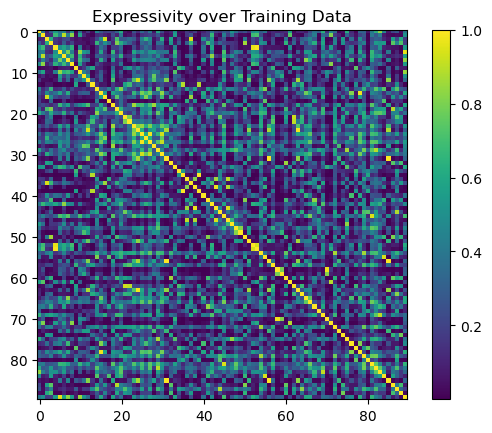

In [11]:
# Properties of the created kernel matrix

print('Mean of the created Kernel Matrix: ', np.mean(kernel_matrix))
print('Variance of the created Kernal Matrix: ', np.var(kernel_matrix))
plt.imshow(kernel_matrix, cmap='viridis')
plt.title("Expressivity over Training Data")
plt.colorbar()
plt.show()

In [12]:
# Now testing with Scikit Learn SVM

qml_svc = SVC(kernel="precomputed")
qml_svc.fit(kernel_matrix, train_labels)
qml_score_precomputed_kernel = qml_svc.score(test_matrix, test_labels)
print(f"Precomputed kernel classification test score: {qml_score_precomputed_kernel}")

Precomputed kernel classification test score: 0.5166666666666667


This part uses Scikit-learn’s SVM with the precomputed quantum kernel obtained from the circuit. The model is trained using the quantum kernel matrix from the training data and then tested using the test matrix to evaluate how well the quantum-generated features perform in classification.

Note that even involving 8 layers of gates, the accuracy we obtain is very modest at just 51.6%. We shall show in the next encoding protocol that even inducing mild entanglement in the circuit gives a massive increase in accuracy.

## Case 2: ZZ Encoding of Feature Vectors (Mild Entanglement Case)

In [13]:
# Defining the additonal involved gates

# Parameter-dependent ZZ Gate
# The Pauli-Z operator
Z = np.array([[1.0, 0.0],
              [0.0, -1.0]])

def ZZ_gate(theta):
    # Create the tensor product Z ⊗ Z representing a two-qubit interaction
    Zt = np.kron(Z, Z)
    
    # Construct the unitary operator exp(-i * θ/2 * Z⊗Z)
    # This applies a phase shift depending on whether the two qubits are aligned (both 0 or both 1)
    gate = la.expm(-1j * theta/2 * Zt) # parameter theta is dependent on input vector
    return gate

This section defines the parameter-dependent ZZ gate, which introduces an entangling interaction between two qubits. The gate applies a relative phase shift based on the joint states of the qubits, making it essential for capturing correlations between features in the data. The strength of this interaction is controlled by the parameter theta, which shall be dependent on the feature vector parameters when used in the encoding scheme.

In [14]:
# Calculating the full kernel matrix for training data
# Repeating the approach as before with the different encoding scheme.

num_samples = np.shape(X_train)[0]
kernel_matrix = np.full((num_samples, num_samples), np.nan)
test_matrix = np.full((test_size, num_samples), np.nan)
ent_map = [(0,1),(1,2),(2,3),(3,0)]

for i in range(0,train_size):
    kernel_matrix[i,i] = 1
    for j in range(i+1,train_size):
        
        vector1 = 2 * np.pi * normalized_values(feature_vectors[i])
        vector2 = 2 * np.pi * normalized_values(feature_vectors[j])
        
        # For feature vector 1
        psi = psi_initial.copy()

        # Applying Hadamard gate to all qubits (First Layer)
        H = H.reshape(2,2)
        for k in range(0,num_qubits):
            psi = np.tensordot(H,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
        
        # Applying the Parameter dependent ZZ gate, based on entanglement map (Second Layer)
        for k in range(0,len(ent_map)):
            pair = ent_map[k]
            param = 2 * (vector1[pair[0]]) * (vector1[pair[1]])
            gate = ZZ_gate(param)
            gate = gate.reshape(2,2,2,2)
            psi = np.tensordot(gate,psi,[[2,3],[pair[0],pair[1]]])
            psi = np.moveaxis(psi,(0,1),(pair[0],pair[1]))
               
        
        # For feature vector 2
        # Applying the Parameter dependent ZZ gate, based on entanglement map (Third Layer)
        for k in range(0,len(ent_map)):
            pair = ent_map[k]
            param = 2 * (vector2[pair[0]]) * (vector2[pair[1]])
            gate = ZZ_gate(param).conj().T
            gate = gate.reshape(2,2,2,2)
            psi = np.tensordot(gate,psi,[[2,3],[pair[0],pair[1]]])
            psi = np.moveaxis(psi,(0,1),(pair[0],pair[1]))
            
        # Applying the Hadamard gate to all qubits (Fourth Layer)
        
        for k in range(0,num_qubits):
            psi = np.tensordot(H,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
        
        
        kernel_matrix[i,j] = np.abs(psi.flatten()[0])**2
        kernel_matrix[j,i] = kernel_matrix[i,j]

This section computes the quantum kernel matrix using an alternative encoding scheme that incorporates entanglement between qubits. Each data sample is encoded into a quantum state through layers of Hadamard and ZZ gates. The Hadamard gates create superpositions, while the parameter-dependent ZZ gates entangle specific pairs of qubits according to the defined entanglement map. The resulting overlap between two encoded states represents their similarity, and the squared magnitude of this overlap forms each element of the kernel matrix used for training the quantum SVM.

In [15]:
# Now repeating the process for testing data

for i in range(0, test_size):
    for j in range(0, train_size):
        
        vector1 = 2 * np.pi * normalized_values(feature_vectors_test[i])
        vector2 = 2 * np.pi * normalized_values(feature_vectors[j])
        
        # For feature vector 1
        psi = psi_initial.copy()

        # Applying Hadamard gate to all qubits
        H = H.reshape(2,2)
        for k in range(0,num_qubits):
            psi = np.tensordot(H,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
        
        # Applying the Parameter dependent ZZ gate, based on entanglement map
        for k in range(0,len(ent_map)):
            pair = ent_map[k]
            param = 2 * (vector1[pair[0]]) * (vector1[pair[1]])
            gate = ZZ_gate(param)
            gate = gate.reshape(2,2,2,2)
            psi = np.tensordot(gate,psi,[[2,3],[pair[0],pair[1]]])
            psi = np.moveaxis(psi,(0,1),(pair[0],pair[1]))
               
        
        # For feature vector 2
        # Applying the Parameter dependent ZZ gate, based on entanglement map
        for k in range(0,len(ent_map)):
            pair = ent_map[k]
            param = 2 * (vector2[pair[0]]) * (vector2[pair[1]])
            gate = ZZ_gate(param).conj().T
            gate = gate.reshape(2,2,2,2)
            psi = np.tensordot(gate,psi,[[2,3],[pair[0],pair[1]]])
            psi = np.moveaxis(psi,(0,1),(pair[0],pair[1]))
            
        # Applying the Hadamard gate to all qubits
        
        for k in range(0,num_qubits):
            psi = np.tensordot(H,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
        
        test_matrix[i,j] = np.abs(psi.flatten()[0])**2

Mean of the created Kernel Matrix:  0.14828630583541305
Variance of the created Kernal Matrix:  0.038736278023015394


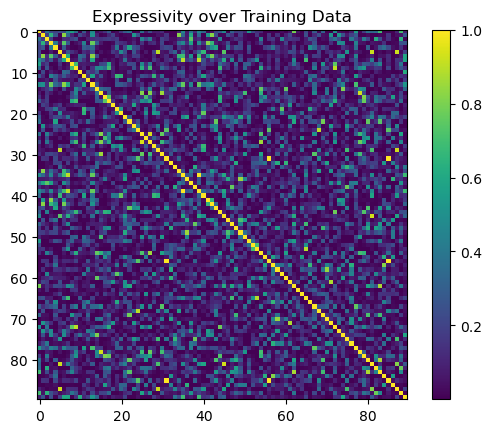

In [16]:
# Properties of the created kernel matrix

print('Mean of the created Kernel Matrix: ', np.mean(kernel_matrix))
print('Variance of the created Kernal Matrix: ', np.var(kernel_matrix))
plt.imshow(kernel_matrix, cmap='viridis')
plt.title("Expressivity over Training Data")
plt.colorbar()
plt.show()

In [17]:
# Now testing with Scikit Learn SVM

qml_svc = SVC(kernel="precomputed")
qml_svc.fit(kernel_matrix, train_labels)
qml_score_precomputed_kernel = qml_svc.score(test_matrix, test_labels)
print(f"Precomputed kernel classification test score: {qml_score_precomputed_kernel}")

Precomputed kernel classification test score: 0.6333333333333333


Note the improvement in results! We have an accuracy of 63.3%, and with half the number of layers as required in the previous phase encoding scheme. This shows the advantage of including entanglement features in the encoding scheme for the feature vectors.

In the final scheme, we shall introduce entanglement is a circuit of high depth, providing the best results obtained so far!

## Case 3: Entanglement and High Depth Circuit (High Entanglement based encoding)

In [18]:
# Defining some additional quantum gates

# RZ Gate: Rotation around the Z-axis of the Bloch sphere
# The angle of rotation is theta
def RZ(theta):
    return np.array([[np.exp(-1j * theta / 2), 0],
                     [0, np.exp(1j * theta / 2)]], dtype=complex)

# RY Gate: Rotation around the Y-axis of the Bloch sphere
# The angle of rotation is theta
def RY(theta):
    return np.array([[np.cos(theta / 2), -np.sin(theta / 2)],
                     [np.sin(theta / 2),  np.cos(theta / 2)]], dtype=complex)

# Controlled-Z (CZ) Gate: Applies a phase shift to the |11> state
def CZ(phi):
    return np.array([[1, 0, 0, 0],
                     [0, 1, 0, 0],
                     [0, 0, 1, 0],
                     [0, 0, 0, np.exp(1j * phi)]], dtype=complex) 

# Parameters theta and phi are dependent on data of the feature vector

This section defines additional single-qubit and two-qubit gates used in the quantum circuit. The RZ and RY gates perform rotations around the Z and Y axes of the qubit, respectively, allowing precise encoding of feature values. The CZ gate is a two-qubit entangling gate that applies a phase shift only when both qubits are in the |11⟩ state, enabling the circuit to capture correlations between qubits. The value of all parameters shall be dependent on the entries of the feature vector, when used in the encoding scheme.

In [19]:
# Calculating the full kernel matrix for training data
# Repeating the same process as followed above for the previous cases with the final encoding scheme

num_samples = np.shape(X_train)[0]
kernel_matrix = np.full((num_samples, num_samples), np.nan)
test_matrix = np.full((test_size, num_samples), np.nan)
ent_map = [(0, 2), (1, 3)]

for i in range(0,train_size):
    kernel_matrix[i,i] = 1
    for j in range(i+1,train_size):
        
        vector1 = 2 * np.pi * normalized_values(feature_vectors[i])
        vector2 = 2 * np.pi * normalized_values(feature_vectors[j])
        
        psi = psi_initial.copy()
        
        # For feature vector 1
        # Applying Hadamard gate to all qubits (First Layer)
        H = H.reshape(2,2)
        for k in range(0,num_qubits):
            psi = np.tensordot(H,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
            
        # Applying RZ and RY to all qubits (Second and Third Layers)
        for k in range(0,num_qubits):
            gate = RZ(vector1[k])
            gate = gate.reshape(2,2)
            psi = np.tensordot(gate,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
            
            gate = RY(vector1[k])
            gate = gate.reshape(2,2)
            psi = np.tensordot(gate,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
        
        # Applying entanglement layer (Fourth Layer)
        for (a, b) in ent_map:
            phi = np.pi * (vector1[a]/(2*np.pi)) * (vector1[b]/(2*np.pi))
            gate = CZ(phi).reshape(2,2,2,2)
            psi = np.tensordot(gate,psi,[[2,3],[a,b]])
            psi = np.moveaxis(psi,(0,1),(a,b))
            
        # For feature vector 2
        # Applying entanglement layer (Fifth Layer)
        for (a, b) in ent_map:
            phi = np.pi * (vector1[a]/(2*np.pi)) * (vector1[b]/(2*np.pi))
            gate = CZ(phi).conj().T
            gate = gate.reshape(2,2,2,2)
            psi = np.tensordot(gate,psi,[[2,3],[a,b]])
            psi = np.moveaxis(psi,(0,1),(a,b))
            
        # Applying RZ and RY to all qubits (Sixth and Seventh Layer)
        for k in range(0,num_qubits):
            gate = RY(-1 * vector2[k])
            gate = gate.reshape(2,2)
            psi = np.tensordot(gate,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
            
            gate = RZ(-1 * vector2[k])
            gate = gate.reshape(2,2)
            psi = np.tensordot(gate,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
            
        # Applying Hadamard gate to all qubits (Eighth Layer)
        H = H.reshape(2,2)
        for k in range(0,num_qubits):
            psi = np.tensordot(H,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
                 
        kernel_matrix[i,j] = np.abs(psi.flatten()[0])**2
        kernel_matrix[j,i] = kernel_matrix[i,j]

This section defines additional single-qubit and two-qubit gates used in the quantum circuit. The RZ and RY gates perform rotations around the Z and Y axes of the qubit, respectively, allowing precise encoding of feature values. The CZ gate is a two-qubit entangling gate that applies a phase shift only when both qubits are in the |11⟩ state, enabling the circuit to capture correlations between qubits.

Note that the entanglement map is also different in this case. Here, we have it as **ent_map = [(0, 2), (1, 3)]**, whereas for the previous case, it was **ent_map = [(0,1),(1,2),(2,3),(3,0)]**. Thereby, we have the case of longer range entanglement in our present case compared to the previous.

In [20]:
# Now repeating the process for testing data

for i in range(0, test_size):
    for j in range(0, train_size):
        
        vector1 = 2 * np.pi * normalized_values(feature_vectors_test[i])
        vector2 = 2 * np.pi * normalized_values(feature_vectors[j])
        
        psi = psi_initial.copy()
        
        # Applying Hadamard gate to all qubits
        H = H.reshape(2,2)
        for k in range(0,num_qubits):
            psi = np.tensordot(H,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
            
        # Applying RZ and RY to all qubits
        for k in range(0,num_qubits):
            gate = RZ(vector1[k])
            gate = gate.reshape(2,2)
            psi = np.tensordot(gate,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
            
            gate = RY(vector1[k])
            gate = gate.reshape(2,2)
            psi = np.tensordot(gate,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
        
        # Applying entanglement layer
        for (a, b) in ent_map:
            phi = np.pi * (vector1[a]/(2*np.pi)) * (vector1[b]/(2*np.pi))
            gate = CZ(phi).reshape(2,2,2,2)
            psi = np.tensordot(gate,psi,[[2,3],[a,b]])
            psi = np.moveaxis(psi,(0,1),(a,b))
            
        # Applying entanglement layer
        for (a, b) in ent_map:
            phi = np.pi * (vector1[a]/(2*np.pi)) * (vector1[b]/(2*np.pi))
            gate = CZ(phi).conj().T
            gate = gate.reshape(2,2,2,2)
            psi = np.tensordot(gate,psi,[[2,3],[a,b]])
            psi = np.moveaxis(psi,(0,1),(a,b))
            
        # Applying RZ and RY to all qubits
        for k in range(0,num_qubits):
            gate = RY(-1 * vector2[k])
            gate = gate.reshape(2,2)
            psi = np.tensordot(gate,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
            
            gate = RZ(-1 * vector2[k])
            gate = gate.reshape(2,2)
            psi = np.tensordot(gate,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
            
        # Applying Hadamard gate to all qubits
        H = H.reshape(2,2)
        for k in range(0,num_qubits):
            psi = np.tensordot(H,psi,[1,k])
            psi = np.moveaxis(psi,0,k)
            
        
        test_matrix[i,j] = np.abs(psi.flatten()[0])**2

Mean of the created Kernel Matrix:  0.4724736809092708
Variance of the created Kernal Matrix:  0.15971990969951175


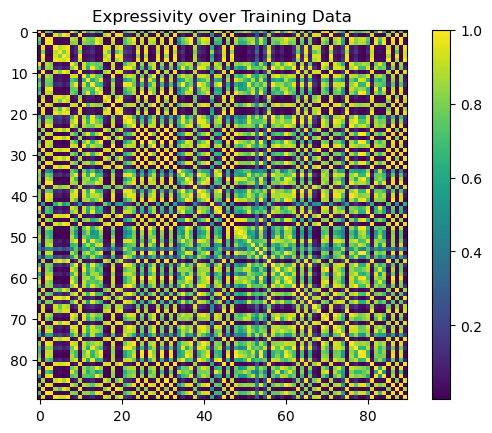

In [21]:
# Properties of the created kernel matrix

print('Mean of the created Kernel Matrix: ', np.mean(kernel_matrix))
print('Variance of the created Kernal Matrix: ', np.var(kernel_matrix))
plt.imshow(kernel_matrix, cmap='viridis')
plt.title("Expressivity over Training Data")
plt.colorbar()
plt.show()

In [22]:
# Now testing with Scikit Learn SVM

qml_svc = SVC(kernel="precomputed")
qml_svc.fit(kernel_matrix, train_labels)
qml_score_precomputed_kernel = qml_svc.score(test_matrix, test_labels)
print(f"Precomputed kernel classification test score: {qml_score_precomputed_kernel}")

Precomputed kernel classification test score: 0.9833333333333333


In this final case we have an accuracy of 98.3%, outperforming the classical benchmark established by the Classical RBF Kernel!!

In this case, we have a circuit of the same depth as case 1, where we had the phase encoding of gates. However, introducing entanglement in a similar circuit depth, we have almost doubled the accuracy of our results.

## Summary and Conclusions

We have demonstrated the use of a Quantum Support Vector Machine which is able to generate a Quantum Kernal that can be effectively used to classify data in a small sized dataset. While the high metrics generated here for the result are only possible to replicate in a Fault-Tolerant Quantum Computer, we none the less indicate the applicability of protocols that can be used for Classification tasks.

We also find that effectively using entanglement can significantly enhance the accuracy of our predictions.

### Disclaimer

Parts of the comments and documentation were refined with the help of an AI assistant (ChatGPT) to enhance clarity and presentation. The underlying approach, methodology, and circuit design were fully conceived and implemented by the author.